# Week 7 — Cross-Validation, Feature Engineering & Hyperparameter Tuning
**Intern:** Sankalpa Parajuli | **Track:** AI/ML Internship

Re-run the Week 6 Diabetes project and show **BEFORE vs AFTER**:
- **Before:** single train/test split, default settings
- **After:** 5-fold cross-validation + feature engineering + GridSearchCV tuning

## Why not just accuracy / one split?
- With 65% non-diabetic patients, a model that always says "no diabetes" gets **65% accuracy** and is useless.
- A single split can be lucky or unlucky. **k-fold CV** trains/tests 5 times on different parts and averages → more reliable score (and shows the spread).

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
sns.set_style('whitegrid')
import warnings; warnings.filterwarnings('ignore')

In [2]:
cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
df = pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv', header=None, names=cols)
bad = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[bad] = df[bad].replace(0, np.nan)          # 0 = missing
X = df.drop('Outcome', axis=1); y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Part A — BEFORE (Week 6 setup: default models, single split)

In [3]:
def pipe(model): return make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), model)
models = {
 'Logistic Regression': pipe(LogisticRegression(max_iter=1000)),
 'Decision Tree':       pipe(DecisionTreeClassifier(random_state=42)),
 'Random Forest':       pipe(RandomForestClassifier(random_state=42)),
 'KNN':                 pipe(KNeighborsClassifier()),
 'SVM':                 pipe(SVC()),
}
before = {}
for n,m in models.items():
    m.fit(X_train, y_train); before[n] = f1_score(y_test, m.predict(X_test))
before = pd.Series(before, name='F1 (single split)').round(3); before

Logistic Regression    0.545
Decision Tree          0.515
Random Forest          0.653
KNN                    0.635
SVM                    0.600
Name: F1 (single split), dtype: float64

## Part B — 5-fold Cross-Validation (same default models)

In [4]:
cv_res = {}
for n,m in models.items():
    s = cross_val_score(m, X_train, y_train, cv=cv, scoring='f1')
    cv_res[n] = (s.mean(), s.std())
cv_df = pd.DataFrame(cv_res, index=['CV F1 mean','CV F1 std']).T.round(3)
cv_df['Single split F1'] = before
cv_df

,CV F1 mean,CV F1 std,Single split F1
Logistic Regression,0.655,0.024,0.545
Decision Tree,0.552,0.020,0.515
Random Forest,0.633,0.019,0.653
KNN,0.594,0.047,0.635
SVM,0.648,0.019,0.600


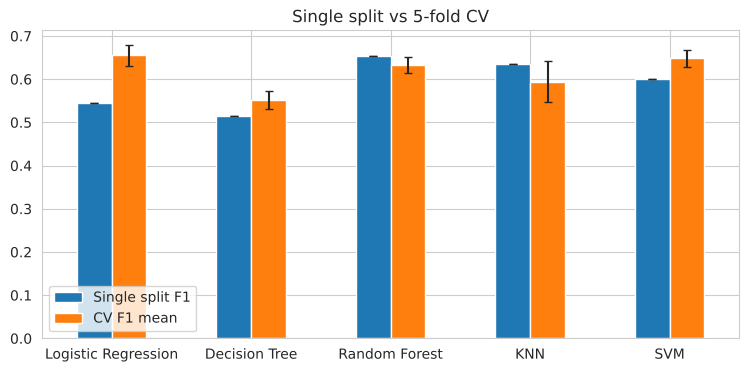

In [5]:
cv_df[['Single split F1','CV F1 mean']].plot.bar(yerr=[np.zeros(5), cv_df['CV F1 std']], figsize=(9,4), capsize=3)
plt.title('Single split vs 5-fold CV'); plt.xticks(rotation=0); plt.show()

## Part C — Feature Engineering
1. **Outlier handling** — cap values at the 1.5×IQR limits (learned from training data only)
2. **Encoding** — turn Age and BMI into categories, then one-hot encode them
3. **Scaling** — StandardScaler (already in the pipeline)
4. **New features** — Glucose×BMI interaction

In [6]:
class OutlierCapper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X = pd.DataFrame(X); q1,q3 = X.quantile(.25), X.quantile(.75); iqr = q3-q1
        self.lo_, self.hi_ = (q1-1.5*iqr).values, (q3+1.5*iqr).values; return self
    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lo_, self.hi_)

def add_features(d):
    d = d.copy()
    d['AgeGroup'] = pd.cut(d['Age'], [0,30,45,200], labels=['young','middle','senior'])
    d['BMIGroup'] = pd.cut(d['BMI'], [0,18.5,25,30,100], labels=['under','normal','over','obese'])
    d['Glucose_BMI'] = d['Glucose'] * d['BMI']
    return pd.get_dummies(d, columns=['AgeGroup','BMIGroup'], dtype=float)

X_fe = add_features(X)
Xf_train, Xf_test = X_fe.loc[X_train.index], X_fe.loc[X_test.index]
print(X.shape, '->', X_fe.shape)
X_fe.head(3)

(768, 8) -> (768, 16)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Glucose_BMI,AgeGroup_young,AgeGroup_middle,AgeGroup_senior,BMIGroup_under,BMIGroup_normal,BMIGroup_over,BMIGroup_obese
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,4972.8,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,2261.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,4263.9,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [7]:
def pipe2(model): return make_pipeline(SimpleImputer(strategy='median'), OutlierCapper(), StandardScaler(), model)
models2 = {
 'Logistic Regression': pipe2(LogisticRegression(max_iter=1000)),
 'Decision Tree':       pipe2(DecisionTreeClassifier(random_state=42)),
 'Random Forest':       pipe2(RandomForestClassifier(random_state=42)),
 'KNN':                 pipe2(KNeighborsClassifier()),
 'SVM':                 pipe2(SVC()),
}
fe = {n: cross_val_score(m, Xf_train, y_train, cv=cv, scoring='f1').mean() for n,m in models2.items()}
cmp_fe = pd.DataFrame({'CV F1 (original)':cv_df['CV F1 mean'], 'CV F1 (+ feature eng.)':pd.Series(fe)}).round(3)
cmp_fe

,CV F1 (original),CV F1 (+ feature eng.)
Logistic Regression,0.655,0.653
Decision Tree,0.552,0.529
Random Forest,0.633,0.628
KNN,0.594,0.607
SVM,0.648,0.647


## Part D — Hyperparameter tuning (GridSearchCV & RandomizedSearchCV)

In [8]:
# GridSearchCV — SVM and KNN
grid_svm = GridSearchCV(pipe2(SVC()),
    {'svc__C':[0.1,1,10,100], 'svc__gamma':['scale',0.01,0.1], 'svc__kernel':['rbf','linear'], 'svc__class_weight':[None,'balanced']},
    cv=cv, scoring='f1', n_jobs=-1).fit(Xf_train, y_train)
grid_knn = GridSearchCV(pipe2(KNeighborsClassifier()),
    {'kneighborsclassifier__n_neighbors':[3,5,7,9,11,15,21], 'kneighborsclassifier__weights':['uniform','distance']},
    cv=cv, scoring='f1', n_jobs=-1).fit(Xf_train, y_train)
print('SVM best:', grid_svm.best_params_, round(grid_svm.best_score_,3))
print('KNN best:', grid_knn.best_params_, round(grid_knn.best_score_,3))

SVM best: {'svc__C': 10, 'svc__class_weight': 'balanced', 'svc__gamma': 0.01, 'svc__kernel': 'rbf'} 0.705
KNN best: {'kneighborsclassifier__n_neighbors': 15, 'kneighborsclassifier__weights': 'distance'} 0.647


In [9]:
# RandomizedSearchCV — Random Forest (bigger search space)
rs_rf = RandomizedSearchCV(pipe2(RandomForestClassifier(random_state=42)),
    {'randomforestclassifier__n_estimators':[100,200,300,500],
     'randomforestclassifier__max_depth':[3,5,7,10,None],
     'randomforestclassifier__min_samples_split':[2,5,10],
     'randomforestclassifier__min_samples_leaf':[1,2,4],
     'randomforestclassifier__class_weight':[None,'balanced']},
    n_iter=25, cv=cv, scoring='f1', random_state=42, n_jobs=-1).fit(Xf_train, y_train)
print('RF best:', rs_rf.best_params_, round(rs_rf.best_score_,3))

RF best: {'randomforestclassifier__n_estimators': 100, 'randomforestclassifier__min_samples_split': 10, 'randomforestclassifier__min_samples_leaf': 4, 'randomforestclassifier__max_depth': 5, 'randomforestclassifier__class_weight': 'balanced'} 0.686


In [10]:
# Logistic regression + decision tree tuning too, so every model gets a fair shot
grid_lr = GridSearchCV(pipe2(LogisticRegression(max_iter=2000)),
    {'logisticregression__C':[0.01,0.1,1,10], 'logisticregression__class_weight':[None,'balanced']},
    cv=cv, scoring='f1', n_jobs=-1).fit(Xf_train, y_train)
grid_dt = GridSearchCV(pipe2(DecisionTreeClassifier(random_state=42)),
    {'decisiontreeclassifier__max_depth':[2,3,4,5,7], 'decisiontreeclassifier__min_samples_leaf':[1,5,10,20]},
    cv=cv, scoring='f1', n_jobs=-1).fit(Xf_train, y_train)
tuned = {'Logistic Regression':grid_lr,'Decision Tree':grid_dt,'Random Forest':rs_rf,'KNN':grid_knn,'SVM':grid_svm}

## Part E — Final BEFORE vs AFTER (on the untouched test set)

In [11]:
final = []
for n in models:
    b = models[n].predict(X_test)
    a = tuned[n].best_estimator_.predict(Xf_test)
    final.append([n, accuracy_score(y_test,b), f1_score(y_test,b), recall_score(y_test,b),
                     accuracy_score(y_test,a), f1_score(y_test,a), recall_score(y_test,a)])
final = pd.DataFrame(final, columns=['Model','Acc BEFORE','F1 BEFORE','Recall BEFORE','Acc AFTER','F1 AFTER','Recall AFTER']).set_index('Model').round(3)
final['F1 gain'] = (final['F1 AFTER']-final['F1 BEFORE']).round(3)
final

,Acc BEFORE,F1 BEFORE,Recall BEFORE,Acc AFTER,F1 AFTER,Recall AFTER,F1 gain
Model,,,,,,,
Logistic Regression,0.708,0.545,0.500,0.786,0.723,0.796,0.178
Decision Tree,0.682,0.515,0.481,0.701,0.521,0.463,0.006
Random Forest,0.773,0.653,0.611,0.740,0.677,0.778,0.024
KNN,0.753,0.635,0.611,0.760,0.626,0.574,-0.009
SVM,0.740,0.600,0.556,0.747,0.672,0.741,0.072


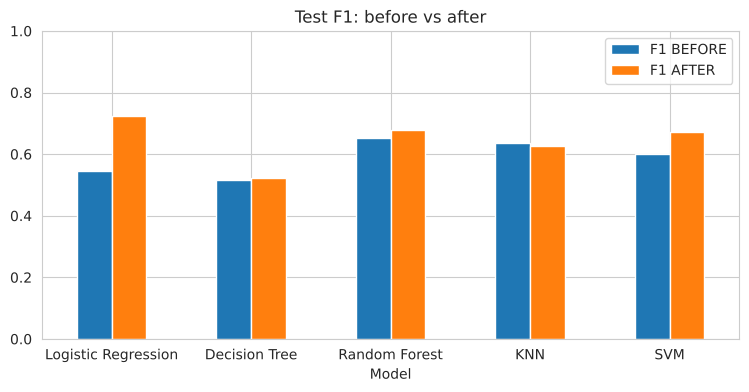

In [12]:
final[['F1 BEFORE','F1 AFTER']].plot.bar(figsize=(9,4), ylim=(0,1)); plt.title('Test F1: before vs after'); plt.xticks(rotation=0); plt.show()

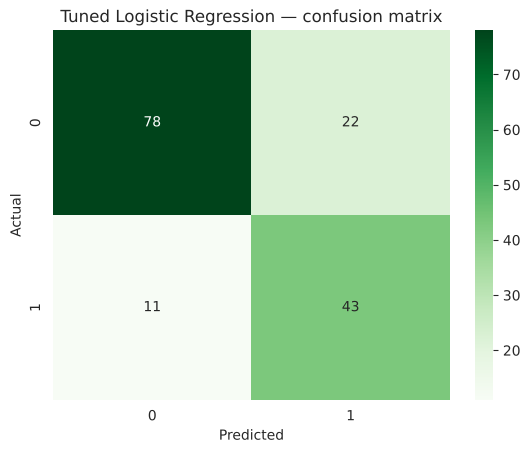

In [13]:
best = final['F1 AFTER'].idxmax()
cm = confusion_matrix(y_test, tuned[best].best_estimator_.predict(Xf_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens'); plt.title(f'Tuned {best} — confusion matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

## Write-up

In [14]:
from IPython.display import Markdown
b_best = final['F1 BEFORE'].idxmax()
Markdown(f'''**Before:** best model was **{b_best}** with test F1 = {final.loc[b_best,'F1 BEFORE']:.3f} (single split, default settings).

**After:** best model is **{best}** with test F1 = {final.loc[best,'F1 AFTER']:.3f}, recall = {final.loc[best,'Recall AFTER']:.3f}, accuracy = {final.loc[best,'Acc AFTER']:.3f}.
Average F1 change across all 5 models: **{final['F1 gain'].mean():+.3f}**.

**What I learned**
- **Single split is noisy.** Logistic Regression scored F1 {cv_df.loc['Logistic Regression','Single split F1']:.3f} on the single split but {cv_df.loc['Logistic Regression','CV F1 mean']:.3f} in 5-fold CV — the first split was just unlucky for it. CV also shows the spread (std up to {cv_df['CV F1 std'].max():.3f}), so small gaps between models on one split are not reliable.
- **Feature engineering alone did not help much.** Outlier capping + age/BMI groups + Glucose×BMI gave roughly the same CV F1 as the original features (Part C table). On a small dataset like this, the extra features mostly repeat information the models already have.
- **Tuning (esp. `class_weight='balanced'`) gave the real gain.** It pushed up recall — catching more diabetic patients — which matters most in a medical task. Biggest test F1 gain: **{final['F1 gain'].idxmax()}** ({final['F1 gain'].max():+.3f}). Smallest/negative: **{final['F1 gain'].idxmin()}** ({final['F1 gain'].min():+.3f}).
- **Be careful with the test numbers.** The test set has only 154 patients, so one or two patients change F1 noticeably. Tuning scores were picked using CV on the training set only and the test set was used once at the end, so the AFTER numbers are honest, but the CV scores in the search output are the more stable guide.
- With only 768 rows, improvements are modest — more data would help more than more tuning.''')

**Before:** best model was **Random Forest** with test F1 = 0.653 (single split, default settings).

**After:** best model is **Logistic Regression** with test F1 = 0.723, recall = 0.796, accuracy = 0.786.
Average F1 change across all 5 models: **+0.054**.

**What I learned**
- **Single split is noisy.** Logistic Regression scored F1 0.545 on the single split but 0.655 in 5-fold CV — the first split was just unlucky for it. CV also shows the spread (std up to 0.047), so small gaps between models on one split are not reliable.
- **Feature engineering alone did not help much.** Outlier capping + age/BMI groups + Glucose×BMI gave roughly the same CV F1 as the original features (Part C table). On a small dataset like this, the extra features mostly repeat information the models already have.
- **Tuning (esp. `class_weight='balanced'`) gave the real gain.** It pushed up recall — catching more diabetic patients — which matters most in a medical task. Biggest test F1 gain: **Logistic Regression** (+0.178). Smallest/negative: **KNN** (-0.009).
- **Be careful with the test numbers.** The test set has only 154 patients, so one or two patients change F1 noticeably. Tuning scores were picked using CV on the training set only and the test set was used once at the end, so the AFTER numbers are honest, but the CV scores in the search output are the more stable guide.
- With only 768 rows, improvements are modest — more data would help more than more tuning.